# Modeling: Report IV MVP Grid Evaluation

This notebook executes the complete Report IV modeling workflow: a 24-experiment
grid comparison of Ridge and HistGradientBoostingRegressor models across four
feature sets at 1-minute resolution, plus baseline benchmarks, an H1 workday
ablation control, hypothesis evaluation, a day-ahead extension, and a one-shot
holdout test.

**Pipeline position**: Fourth analytical step. Follows gold-layer filtering
(`scripts/002_silver_to_gold.py`) and model dataset splitting
(`scripts/003_create_model_datasets.py`). Consumes model-split parquet files
from `data/004_model/`.

**Input**: Model-split parquet files in `data/004_model/` (12 files: 1
resolution x 4 feature sets x 3 splits), plus gold parquet for baseline
computation.

**Key outputs**:
- 24 grid experiment results (4 feature sets x 6 model configurations)
- 3 baseline benchmarks (persistence, previous-day, average workday profile)
- 1 H1 control experiment (workday ablation)
- 1 day-ahead extension experiment
- Hypothesis evaluation table (H1-H4)
- One-shot holdout test with coverage-guarded model selection
- Artifact pack in `outputs/step4_artifacts/`:
  `metrics_overall.csv`, `metrics_by_day_class.csv`, `metrics_by_hour.csv`,
  `run_manifest.json`, and 4 PNG figures

**Configuration**: Model grid, feature sets, and split ranges are defined in
[`config/pipeline.toml`](../config/pipeline.toml) and loaded via
[`scripts/config.py`](../scripts/config.py). Seed is fixed at 42 for
reproducibility.

**Related references**:
- Feature sets: [`docs/003_modeling/feature_sets.md`](../docs/003_modeling/feature_sets.md)
- Hypotheses: [`docs/003_modeling/hypothesis.md`](../docs/003_modeling/hypothesis.md)
- MVMP: [`docs/003_modeling/mvmp.md`](../docs/003_modeling/mvmp.md)
- Run summary: [`docs/003_modeling/report_iv_run_summary.md`](../docs/003_modeling/report_iv_run_summary.md)
- Architecture: [`docs/001_architecture/005_model/model.md`](../docs/001_architecture/005_model/model.md)

In [1]:
import sys
import json
import logging
import warnings
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "pipeline.toml").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing config/pipeline.toml")


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import (
    FEATURE_SETS,
    PATHS,
    SPLIT_DAY_RANGES,
    TARGET_COLUMN,
    RESOLUTION_TO_SUFFIX,
    get_gold_path,
    validate_config,
)

validate_config()

RESOLUTIONS = ["1min"]
SUFFIXES = {r: RESOLUTION_TO_SUFFIX[r] for r in RESOLUTIONS}
FEATURE_SET_NAMES = list(FEATURE_SETS.keys())
SEED = 42
MIN_VALIDATE_COVERAGE = 0.95
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "step4_artifacts"
OHE_COLUMNS = ["workday", "hour", "day_of_week", "season", "time_of_day"]
PERIODS_PER_DAY = {"1min": 1440, "5min": 288, "10min": 144}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

warnings.filterwarnings("ignore", category=UserWarning)
logging.basicConfig(level=logging.INFO, format="%(message)s")
log = logging.getLogger(__name__)

relative_output_dir = OUTPUT_DIR.relative_to(PROJECT_ROOT)
log.info("Project root resolved from config/pipeline.toml.")
log.info("Output dir (repo-relative): %s", relative_output_dir)
log.info("MVP resolutions: %s", RESOLUTIONS)


Project root resolved from config/pipeline.toml.


Output dir (repo-relative): outputs\step4_artifacts


MVP resolutions: ['1min']


## Pre-Run Integrity Checks and Data Loading

Before any modeling begins, `pre_run_checks()` validates that:

- All 12 required model-split files exist (1 resolution x 4 feature sets x 3 splits).
- Feature sets in `config/pipeline.toml` match the expected names.
- No target leakage exists in any feature set.
- Gold schema contains all required feature columns.
- Train/validate chronology is strictly ordered (no future data leaking into training).

A passing check gates the rest of the notebook. Failure raises a `RuntimeError`
with a count of violations.

In [2]:
def load_split(resolution: str, feature_set: str, split: str) -> pd.DataFrame:
    suffix = SUFFIXES[resolution]
    path = PATHS["model_dir"] / f"{suffix}_{feature_set}_{split}.parquet"
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df


def load_gold(resolution: str) -> pd.DataFrame:
    path = get_gold_path(resolution)
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df


def pre_run_checks() -> None:
    errors: list[str] = []

    expected_feature_sets = {"minimal", "temporal", "curated", "full"}
    if set(FEATURE_SET_NAMES) != expected_feature_sets:
        errors.append(f"FEATURE_SET_NAMES mismatch: {set(FEATURE_SET_NAMES)} != {expected_feature_sets}")

    for fs_name, cols in FEATURE_SETS.items():
        if TARGET_COLUMN in cols:
            errors.append(f"Target leakage in FEATURE_SETS['{fs_name}']")

    # Verify required model split files for MVP scope (1min only)
    suffix = SUFFIXES["1min"]
    for fs_name in ["minimal", "temporal", "curated", "full"]:
        for split in ["train", "validate", "test"]:
            p = PATHS["model_dir"] / f"{suffix}_{fs_name}_{split}.parquet"
            if not p.exists():
                errors.append(f"Missing model split file: {p}")

    gold = load_gold("1min")
    gold_cols = set(gold.columns)
    for fs_name, cols in FEATURE_SETS.items():
        missing = set(cols) - gold_cols
        if missing:
            errors.append(f"Gold schema missing columns for {fs_name}: {sorted(missing)}")

    train = load_split("1min", "minimal", "train")
    val = load_split("1min", "minimal", "validate")
    if train["timestamp"].max() >= val["timestamp"].min():
        errors.append("Chronology violation: train max timestamp >= validate min timestamp")

    if errors:
        for err in errors:
            log.error("PRE-RUN CHECK FAILED: %s", err)
        raise RuntimeError(f"{len(errors)} pre_run_checks failed")

    log.info("pre_run_checks passed")


pre_run_checks()

_check = load_split("1min", "minimal", "train")
assert TARGET_COLUMN in _check.columns
assert "timestamp" in _check.columns
assert "lag_1" in _check.columns
assert TARGET_COLUMN not in FEATURE_SETS["minimal"]
log.info("Verification OK: 1min minimal train rows=%d cols=%d", len(_check), len(_check.columns))


pre_run_checks passed


Verification OK: 1min minimal train rows=35984 cols=6


## Utility Functions

Three functions support the experiment grid:

- **`prepare_xy`** -- Separates feature columns from the target, optionally
  dropping rows with NaN in any feature or target column. Ridge models require
  `drop_na=True` (cannot handle missing values); HGB models use `drop_na=False`
  (native NaN support), which produces different evaluation set sizes across
  model families.
- **`encode_for_ridge`** -- Applies one-hot encoding with `drop_first=True` to
  categorical columns (`workday`, `hour`, `day_of_week`, `season`,
  `time_of_day`) and aligns train/eval column sets. HGB models skip this step
  and use raw numeric features.
- **`compute_grouped_metrics`** -- Computes MAE and RMSE grouped by a
  categorical variable (day class or hour), used for the breakdown CSV exports.

In [3]:
def prepare_xy(df: pd.DataFrame, feature_cols: list[str], drop_na: bool = True) -> tuple[pd.DataFrame, pd.Series]:
    work = df.copy()
    keep_cols = [*feature_cols, TARGET_COLUMN]
    work = work[keep_cols]

    if drop_na:
        work = work.dropna(subset=keep_cols)
    else:
        work = work[work[TARGET_COLUMN].notna()]

    x = work[feature_cols].copy()
    y = work[TARGET_COLUMN].copy()
    return x, y


def encode_for_ridge(train_x: pd.DataFrame, eval_x: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ohe_cols = [col for col in OHE_COLUMNS if col in train_x.columns]
    train_e = train_x.copy()
    eval_e = eval_x.copy()

    if ohe_cols:
        train_e[ohe_cols] = train_e[ohe_cols].astype("category")
        eval_e[ohe_cols] = eval_e[ohe_cols].astype("category")

        train_e = pd.get_dummies(train_e, columns=ohe_cols, drop_first=True)
        eval_e = pd.get_dummies(eval_e, columns=ohe_cols, drop_first=True)

        train_e, eval_e = train_e.align(eval_e, join="left", axis=1, fill_value=0.0)
        eval_e = eval_e.reindex(columns=train_e.columns, fill_value=0.0)

    train_e.columns = [str(c).replace(".0", "") for c in train_e.columns]
    eval_e.columns = [str(c).replace(".0", "") for c in eval_e.columns]
    return train_e, eval_e


def compute_grouped_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    group_values: pd.Series,
    group_name: str,
) -> pd.DataFrame:
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        group_name: group_values.to_numpy(),
    })

    rows = []
    for value, grp in df.groupby(group_name):
        rows.append({
            group_name: value,
            "mae": mean_absolute_error(grp["y_true"], grp["y_pred"]),
            "rmse": float(np.sqrt(mean_squared_error(grp["y_true"], grp["y_pred"]))),
            "n_rows": int(len(grp)),
        })
    return pd.DataFrame(rows).sort_values(group_name).reset_index(drop=True)

## Baselines

Three baselines anchor the model comparison:

1. **Persistence (lag_1)** -- Predicts the next value as the most recent
   observation. The strongest naive benchmark for high-frequency time series.
2. **Previous-day** -- Shifts the gold-layer load by `periods_per_day` (1,440
   at 1-minute resolution) to predict the same minute one day prior.
3. **Average workday profile** -- Computes the mean load for each
   (workday, hour) combination from the training split and applies it as the
   prediction for each validation row.

In [4]:
def _split_date_bounds(resolution: str, split: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    start_day, end_day = SPLIT_DAY_RANGES[split]
    gold = load_gold(resolution).sort_values("timestamp")
    days = pd.Index(gold["timestamp"].dt.normalize().unique()).sort_values()
    start = pd.Timestamp(days[start_day - 1])
    end = pd.Timestamp(days[end_day - 1]) + pd.Timedelta(days=1)
    return start, end


def _coverage(n_eval: int, n_total: int) -> float:
    if n_total <= 0:
        return 0.0
    return float(n_eval / n_total)


def compute_baselines(resolution: str, split: str = "validate") -> list[dict]:
    df_eval = load_split(resolution, "minimal", split).sort_values("timestamp").copy()
    df_gold = load_gold(resolution).sort_values("timestamp").copy()
    eval_total = int(df_eval[TARGET_COLUMN].notna().sum())

    # Persistence baseline (lag_1 is already in minimal set)
    mask_p = df_eval[[TARGET_COLUMN, "lag_1"]].notna().all(axis=1)
    yp = df_eval.loc[mask_p, "lag_1"].to_numpy()
    yt = df_eval.loc[mask_p, TARGET_COLUMN].to_numpy()

    results: list[dict] = [{
        "experiment": "baseline",
        "resolution": resolution,
        "feature_set": "n/a",
        "model": "persistence",
        "params": "lag_1",
        "encoding": "n/a",
        "split": split,
        "mae": mean_absolute_error(yt, yp),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "n_train": 0,
        "n_eval": int(len(yt)),
        "n_eval_total": eval_total,
        "eval_coverage": _coverage(int(len(yt)), eval_total),
        "train_mae": np.nan,
        "train_rmse": np.nan,
    }]

    # Previous-day baseline from continuous gold series
    periods = PERIODS_PER_DAY[resolution]
    df_gold["prev_day_load"] = df_gold[TARGET_COLUMN].shift(periods)

    split_start, split_end = _split_date_bounds(resolution, split)
    gold_eval = df_gold[(df_gold["timestamp"] >= split_start) & (df_gold["timestamp"] < split_end)].copy()
    gold_eval_total = int(gold_eval[TARGET_COLUMN].notna().sum())
    mask_pd = gold_eval[[TARGET_COLUMN, "prev_day_load"]].notna().all(axis=1)
    yp_pd = gold_eval.loc[mask_pd, "prev_day_load"].to_numpy()
    yt_pd = gold_eval.loc[mask_pd, TARGET_COLUMN].to_numpy()

    results.append({
        "experiment": "baseline",
        "resolution": resolution,
        "feature_set": "n/a",
        "model": "previous_day",
        "params": "shift(periods_per_day)",
        "encoding": "n/a",
        "split": split,
        "mae": mean_absolute_error(yt_pd, yp_pd),
        "rmse": float(np.sqrt(mean_squared_error(yt_pd, yp_pd))),
        "n_train": 0,
        "n_eval": int(len(yt_pd)),
        "n_eval_total": gold_eval_total,
        "eval_coverage": _coverage(int(len(yt_pd)), gold_eval_total),
        "train_mae": np.nan,
        "train_rmse": np.nan,
    })

    # Avg workday profile baseline from train split
    df_train = load_split(resolution, "minimal", "train").copy()
    profile = (
        df_train.groupby(["workday", "hour"], observed=True)[TARGET_COLUMN]
        .mean()
        .rename("avg_workday_load")
        .reset_index()
    )
    df_eval_profile = df_eval.merge(profile, on=["workday", "hour"], how="left")
    mask_aw = df_eval_profile[[TARGET_COLUMN, "avg_workday_load"]].notna().all(axis=1)
    yp_aw = df_eval_profile.loc[mask_aw, "avg_workday_load"].to_numpy()
    yt_aw = df_eval_profile.loc[mask_aw, TARGET_COLUMN].to_numpy()

    results.append({
        "experiment": "baseline",
        "resolution": resolution,
        "feature_set": "n/a",
        "model": "avg_workday",
        "params": "mean(workday,hour)",
        "encoding": "n/a",
        "split": split,
        "mae": mean_absolute_error(yt_aw, yp_aw),
        "rmse": float(np.sqrt(mean_squared_error(yt_aw, yp_aw))),
        "n_train": int(len(df_train)),
        "n_eval": int(len(yt_aw)),
        "n_eval_total": eval_total,
        "eval_coverage": _coverage(int(len(yt_aw)), eval_total),
        "train_mae": np.nan,
        "train_rmse": np.nan,
    })

    return results


In [5]:
baseline_results = []
for res in RESOLUTIONS:
    baseline_results.extend(compute_baselines(resolution=res, split="validate"))

df_baselines = pd.DataFrame(baseline_results)
log.info("Baseline rows: %d", len(df_baselines))
display(df_baselines[["resolution", "model", "mae", "rmse", "n_eval"]])

Baseline rows: 3


,resolution,model,mae,rmse,n_eval
0,1min,persistence,594.717040,1195.946844,4294
1,1min,previous_day,3777.825728,6289.666367,4296
2,1min,avg_workday,2107.586194,3599.405931,4296


## Model Grid Configuration and Experiment Execution

The grid evaluates six model configurations across four feature sets:

**Model configurations** (6 total):
- Ridge with alpha = 0.1 (light), 1.0 (medium), 10.0 (strong)
- HistGradientBoostingRegressor with conservative, balanced, and aggressive
  depth/iteration settings (all seeded at 42)

**Feature sets** (4 total):
- **minimal** (3 features): workday, hour, lag_1
- **temporal** (10 features): calendar features + lag_1
- **curated** (11 features): selected lags, rolling stats, and slope
- **full** (41 features): all engineered features from the gold schema

This produces 24 experiments (4 x 6). Each experiment records MAE, RMSE,
training metrics, and evaluation coverage (`n_eval / n_eval_total`).

**Coverage note**: Ridge models require complete cases after one-hot encoding,
so `n_eval` varies by feature set. The `full` feature set loses significant
coverage due to `rolling_*_1440` NaN cascade from time gaps in the gold series.
HGB models handle NaN natively and always achieve full coverage.

In [6]:
MODEL_CONFIGS = {
    ("ridge", "light"): {"class": Ridge, "params": {"alpha": 0.1}},
    ("ridge", "medium"): {"class": Ridge, "params": {"alpha": 1.0}},
    ("ridge", "strong"): {"class": Ridge, "params": {"alpha": 10.0}},
    ("hgb", "conservative"): {
        "class": HistGradientBoostingRegressor,
        "params": {
            "max_depth": 3,
            "max_iter": 100,
            "learning_rate": 0.1,
            "early_stopping": False,
            "random_state": SEED,
        },
    },
    ("hgb", "balanced"): {
        "class": HistGradientBoostingRegressor,
        "params": {
            "max_depth": 5,
            "max_iter": 200,
            "learning_rate": 0.1,
            "early_stopping": False,
            "random_state": SEED,
        },
    },
    ("hgb", "aggressive"): {
        "class": HistGradientBoostingRegressor,
        "params": {
            "max_depth": 7,
            "max_iter": 300,
            "learning_rate": 0.05,
            "early_stopping": False,
            "random_state": SEED,
        },
    },
}

In [7]:
def run_experiment(
    resolution: str,
    feature_set_name: str,
    model_name: str,
    param_label: str,
    eval_split: str = "validate",
) -> dict:
    cfg = MODEL_CONFIGS[(model_name, param_label)]
    feature_cols = FEATURE_SETS[feature_set_name]

    df_train = load_split(resolution, feature_set_name, "train")
    df_eval = load_split(resolution, feature_set_name, eval_split)
    eval_total = int(df_eval[TARGET_COLUMN].notna().sum())

    if model_name == "ridge":
        x_train, y_train = prepare_xy(df_train, feature_cols, drop_na=True)
        x_eval, y_eval = prepare_xy(df_eval, feature_cols, drop_na=True)
        x_train_e, x_eval_e = encode_for_ridge(x_train, x_eval)
        estimator = cfg["class"](**cfg["params"])
        estimator.fit(x_train_e, y_train)
        y_pred = estimator.predict(x_eval_e)
        y_train_pred = estimator.predict(x_train_e)
        encoding = "ohe"
        n_train = int(len(x_train_e))
    else:
        x_train, y_train = prepare_xy(df_train, feature_cols, drop_na=False)
        x_eval, y_eval = prepare_xy(df_eval, feature_cols, drop_na=False)
        estimator = cfg["class"](**cfg["params"])
        estimator.fit(x_train, y_train)
        y_pred = estimator.predict(x_eval)
        y_train_pred = estimator.predict(x_train)
        encoding = "raw"
        n_train = int(len(x_train))

    eval_rows = df_eval.loc[y_eval.index, ["timestamp", "day_class", "hour"]].copy()
    n_eval = int(len(y_eval))

    return {
        "experiment": "grid",
        "resolution": resolution,
        "feature_set": feature_set_name,
        "model": model_name,
        "params": param_label,
        "encoding": encoding,
        "split": eval_split,
        "mae": float(mean_absolute_error(y_eval, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_eval, y_pred))),
        "n_train": n_train,
        "n_eval": n_eval,
        "n_eval_total": eval_total,
        "eval_coverage": _coverage(n_eval, eval_total),
        "train_mae": float(mean_absolute_error(y_train, y_train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_train_pred))),
        "_y_true": y_eval.to_numpy(),
        "_y_pred": np.asarray(y_pred),
        "_meta": eval_rows.reset_index(drop=True),
    }


all_results: list[dict] = []
for res in RESOLUTIONS:
    for fs_name in FEATURE_SET_NAMES:
        for (model_name, param_label) in MODEL_CONFIGS.keys():
            all_results.append(
                run_experiment(
                    resolution=res,
                    feature_set_name=fs_name,
                    model_name=model_name,
                    param_label=param_label,
                    eval_split="validate",
                )
            )

log.info("Grid experiment rows: %d", len(all_results))


Grid experiment rows: 24


## H1 Control: Workday Ablation

Hypothesis H1 tests whether the `workday` feature provides at least 10% MAE
improvement. The control experiment removes `workday` from the temporal feature
set and trains a Ridge model (alpha = 1.0) on the remaining features. Comparing
this control's MAE against the minimal/ridge-medium treatment isolates the
marginal contribution of the workday signal.

In [8]:
def run_h1_control(resolution: str = "1min") -> dict:
    # temporal minus workday
    feature_cols = [col for col in FEATURE_SETS["temporal"] if col != "workday"]
    df_train = load_split(resolution, "temporal", "train")
    df_eval = load_split(resolution, "temporal", "validate")
    eval_total = int(df_eval[TARGET_COLUMN].notna().sum())

    x_train, y_train = prepare_xy(df_train, feature_cols, drop_na=True)
    x_eval, y_eval = prepare_xy(df_eval, feature_cols, drop_na=True)
    x_train_e, x_eval_e = encode_for_ridge(x_train, x_eval)

    model = Ridge(alpha=1.0)
    model.fit(x_train_e, y_train)

    y_pred = model.predict(x_eval_e)
    y_train_pred = model.predict(x_train_e)
    eval_rows = df_eval.loc[y_eval.index, ["timestamp", "day_class", "hour"]].copy()
    n_eval = int(len(y_eval))

    return {
        "experiment": "h1_control",
        "resolution": resolution,
        "feature_set": "temporal_no_workday",
        "model": "ridge",
        "params": "medium",
        "encoding": "ohe",
        "split": "validate",
        "mae": float(mean_absolute_error(y_eval, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_eval, y_pred))),
        "n_train": int(len(x_train_e)),
        "n_eval": n_eval,
        "n_eval_total": eval_total,
        "eval_coverage": _coverage(n_eval, eval_total),
        "train_mae": float(mean_absolute_error(y_train, y_train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_train_pred))),
        "_y_true": y_eval.to_numpy(),
        "_y_pred": np.asarray(y_pred),
        "_meta": eval_rows.reset_index(drop=True),
    }


h1_result = run_h1_control("1min")
all_results.append(h1_result)
log.info("Total experiment rows after H1 control: %d", len(all_results))

Total experiment rows after H1 control: 25


## Results Assembly, Hypothesis Evaluation, and Determinism

This cell performs three tasks:

1. **Results assembly** -- Merges baseline rows and experiment rows into
   `df_all`, the unified validation results table used for all downstream
   analysis and export.

2. **Hypothesis evaluation** -- `evaluate_hypotheses()` computes the four
   hypothesis metrics:
   - **H1 (workday signal)**: MAE delta between `temporal_no_workday` control
     and `minimal/ridge-medium` treatment. Target: >=10%.
   - **H2 (lag/rolling value)**: RMSE delta between `temporal/ridge-medium`
     and `curated/ridge-medium`. Target: >=8%.
   - **H3 (resolution tradeoff)**: Deferred -- requires multi-resolution data.
   - **H4 (nonlinear behavior)**: Exploratory MAE comparison between
     `curated/ridge-medium` and `curated/hgb-conservative`.

3. **Determinism spot checks** -- Re-runs two representative experiments
   (minimal/ridge-medium and temporal/hgb-balanced) to confirm identical
   results within floating-point tolerance.

In [9]:
df_results = pd.DataFrame([{k: v for k, v in row.items() if not k.startswith("_")} for row in all_results])
df_all = pd.concat([df_baselines, df_results], ignore_index=True)

for col in ["feature_set", "encoding"]:
    df_all[col] = df_all[col].astype(object).where(df_all[col].notna(), "n/a")

df_all["model_label"] = np.where(
    df_all["experiment"].eq("baseline"),
    df_all["model"],
    df_all["model"] + "-" + df_all["params"],
)

df_all["eval_coverage"] = pd.to_numeric(df_all["eval_coverage"], errors="coerce").fillna(0.0)

log.info("df_all rows: %d (%d baselines + %d experiments)", len(df_all), len(df_baselines), len(df_results))

display(
    df_all[df_all["split"].eq("validate")]
    .sort_values("mae")
    .head(10)
    [["experiment", "resolution", "feature_set", "model_label", "mae", "rmse", "n_train", "n_eval", "n_eval_total", "eval_coverage"]]
)


def evaluate_hypotheses(df: pd.DataFrame) -> pd.DataFrame:
    val = df[df["split"].eq("validate")].copy()
    rows: list[dict] = []

    # H1: h1_control vs minimal/ridge/medium (spec-aligned)
    h1_control = val[(val["experiment"] == "h1_control") & (val["resolution"] == "1min")].iloc[0]
    h1_treat = val[
        (val["experiment"] == "grid")
        & (val["resolution"] == "1min")
        & (val["feature_set"] == "minimal")
        & (val["model"] == "ridge")
        & (val["params"] == "medium")
    ].iloc[0]
    h1_delta = (float(h1_control["mae"]) - float(h1_treat["mae"])) / float(h1_control["mae"]) * 100.0
    rows.append({
        "hypothesis": "H1",
        "metric": "mae",
        "control": "temporal_no_workday/ridge-medium",
        "treatment": "minimal/ridge-medium",
        "control_value": float(h1_control["mae"]),
        "treatment_value": float(h1_treat["mae"]),
        "delta_pct": h1_delta,
        "target": ">=10%",
        "passed": h1_delta >= 10.0,
        "control_n_eval": int(h1_control["n_eval"]),
        "treatment_n_eval": int(h1_treat["n_eval"]),
    })

    # H2: temporal/ridge/medium vs curated/ridge/medium (RMSE)
    h2_control = val[
        (val["experiment"] == "grid")
        & (val["resolution"] == "1min")
        & (val["feature_set"] == "temporal")
        & (val["model"] == "ridge")
        & (val["params"] == "medium")
    ].iloc[0]
    h2_treat = val[
        (val["experiment"] == "grid")
        & (val["resolution"] == "1min")
        & (val["feature_set"] == "curated")
        & (val["model"] == "ridge")
        & (val["params"] == "medium")
    ].iloc[0]
    h2_delta = (float(h2_control["rmse"]) - float(h2_treat["rmse"])) / float(h2_control["rmse"]) * 100.0
    rows.append({
        "hypothesis": "H2",
        "metric": "rmse",
        "control": "temporal/ridge-medium",
        "treatment": "curated/ridge-medium",
        "control_value": float(h2_control["rmse"]),
        "treatment_value": float(h2_treat["rmse"]),
        "delta_pct": h2_delta,
        "target": ">=8%",
        "passed": h2_delta >= 8.0,
        "control_n_eval": int(h2_control["n_eval"]),
        "treatment_n_eval": int(h2_treat["n_eval"]),
    })

    # H3 deferred in MVP
    rows.append({
        "hypothesis": "H3",
        "metric": "mae",
        "control": "1min",
        "treatment": "5min",
        "control_value": np.nan,
        "treatment_value": np.nan,
        "delta_pct": np.nan,
        "target": "<=5% degradation",
        "passed": "DEFERRED",
        "control_n_eval": 0,
        "treatment_n_eval": 0,
    })

    # H4 exploratory: curated hgb-conservative vs curated ridge-medium
    h4_control = val[
        (val["experiment"] == "grid")
        & (val["resolution"] == "1min")
        & (val["feature_set"] == "curated")
        & (val["model"] == "ridge")
        & (val["params"] == "medium")
    ].iloc[0]
    h4_treat = val[
        (val["experiment"] == "grid")
        & (val["resolution"] == "1min")
        & (val["feature_set"] == "curated")
        & (val["model"] == "hgb")
        & (val["params"] == "conservative")
    ].iloc[0]
    h4_delta = (float(h4_control["mae"]) - float(h4_treat["mae"])) / float(h4_control["mae"]) * 100.0
    rows.append({
        "hypothesis": "H4",
        "metric": "mae",
        "control": "curated/ridge-medium",
        "treatment": "curated/hgb-conservative",
        "control_value": float(h4_control["mae"]),
        "treatment_value": float(h4_treat["mae"]),
        "delta_pct": h4_delta,
        "target": "exploratory",
        "passed": "EXPLORATORY",
        "control_n_eval": int(h4_control["n_eval"]),
        "treatment_n_eval": int(h4_treat["n_eval"]),
    })

    return pd.DataFrame(rows)


df_hypotheses = evaluate_hypotheses(df_all)
log.info("Hypothesis rows: %d", len(df_hypotheses))
display(df_hypotheses)


def run_determinism_spot_checks() -> None:
    checks = [
        ("1min", "minimal", "ridge", "medium", 1e-10),
        ("1min", "temporal", "hgb", "balanced", 1e-8),
    ]
    for resolution, fs_name, model_name, param_label, tol in checks:
        run_a = run_experiment(resolution, fs_name, model_name, param_label, eval_split="validate")
        run_b = run_experiment(resolution, fs_name, model_name, param_label, eval_split="validate")
        mae_diff = abs(float(run_a["mae"]) - float(run_b["mae"]))
        rmse_diff = abs(float(run_a["rmse"]) - float(run_b["rmse"]))
        if mae_diff > tol or rmse_diff > tol:
            raise AssertionError(
                f"Determinism check failed for {fs_name}/{model_name}-{param_label}: "
                f"mae_diff={mae_diff}, rmse_diff={rmse_diff}, tol={tol}"
            )
        log.info(
            "Determinism OK for %s/%s-%s (tol=%g)",
            fs_name,
            model_name,
            param_label,
            tol,
        )


run_determinism_spot_checks()


df_all rows: 28 (3 baselines + 25 experiments)


,experiment,resolution,feature_set,model_label,mae,rmse,n_train,n_eval,n_eval_total,eval_coverage
23,grid,1min,full,ridge-strong,435.003937,835.194568,26169,1612,4296,0.375233
22,grid,1min,full,ridge-medium,435.800426,835.389672,26169,1612,4296,0.375233
21,grid,1min,full,ridge-light,435.886050,835.411051,26169,1612,4296,0.375233
26,grid,1min,full,hgb-aggressive,517.447107,949.805831,35984,4296,4296,1.000000
25,grid,1min,full,hgb-balanced,522.205682,959.904648,35984,4296,4296,1.000000
24,grid,1min,full,hgb-conservative,569.570548,985.126554,35984,4296,4296,1.000000
0,baseline,1min,n/a,persistence,594.717040,1195.946844,0,4294,4296,0.999534
17,grid,1min,curated,ridge-strong,601.290146,1134.076600,34109,4152,4296,0.966480
16,grid,1min,curated,ridge-medium,601.374335,1134.088672,34109,4152,4296,0.966480
15,grid,1min,curated,ridge-light,601.382912,1134.089924,34109,4152,4296,0.966480


Hypothesis rows: 4


,hypothesis,metric,control,treatment,control_value,treatment_value,delta_pct,target,passed,control_n_eval,treatment_n_eval
0,H1,mae,temporal_no_workday/ridge-medium,minimal/ridge-medium,647.670472,651.767551,-0.632587,>=10%,False,4294,4294
1,H2,rmse,temporal/ridge-medium,curated/ridge-medium,1188.326604,1134.088672,4.564228,>=8%,False,4294,4152
2,H3,mae,1min,5min,NaN,NaN,NaN,<=5% degradation,DEFERRED,0,0
3,H4,mae,curated/ridge-medium,curated/hgb-conservative,601.374335,662.050211,-10.089535,exploratory,EXPLORATORY,4152,4296


Determinism OK for minimal/ridge-medium (tol=1e-10)


Determinism OK for temporal/hgb-balanced (tol=1e-08)


## Validation Visualizations

Four saved figures provide the core visual evidence for the report:

1. **Actual vs predicted overlay** (`fig_actual_vs_predicted.png`)
   - **Purpose**: Overlays actual load, model predictions (curated/ridge-medium),
     and the persistence baseline on the first two days of the validation split.
   - **Look for**: The model curve should track the actual load more closely
     than persistence during ramp transitions (morning startup, evening
     shutdown). Persistent gaps between model and actual indicate systematic
     bias at specific times of day.

2. **MAE by hour of day** (`fig_error_by_hour.png`)
   - **Purpose**: Plots hourly MAE for the top 4 models to reveal time-of-day
     error patterns.
   - **Look for**: Error peaks during morning ramp (hours 6-9) and evening
     transition (hours 17-20) are expected. Low error during stable nighttime
     hours (0-5, 22-23) confirms the model handles base load well. A model
     that reduces peak-hour error relative to others has practical value for
     demand planning.

3. **Model comparison bar chart** (`fig_model_comparison.png`)
   - **Purpose**: Ranks all validation experiments by MAE in a single bar
     chart, color-coded by experiment type (grid, baseline, H1 control).
   - **Look for**: The persistence baseline serves as the reference bar.
     Models below persistence demonstrate genuine predictive value. The gap
     between Ridge and HGB on the same feature set reveals the nonlinear
     signal captured by tree-based models.

4. **Resolution comparison** (deferred for 1min MVP)
   - Skipped when only one resolution is evaluated. Will be enabled when
     multi-resolution runs are added.

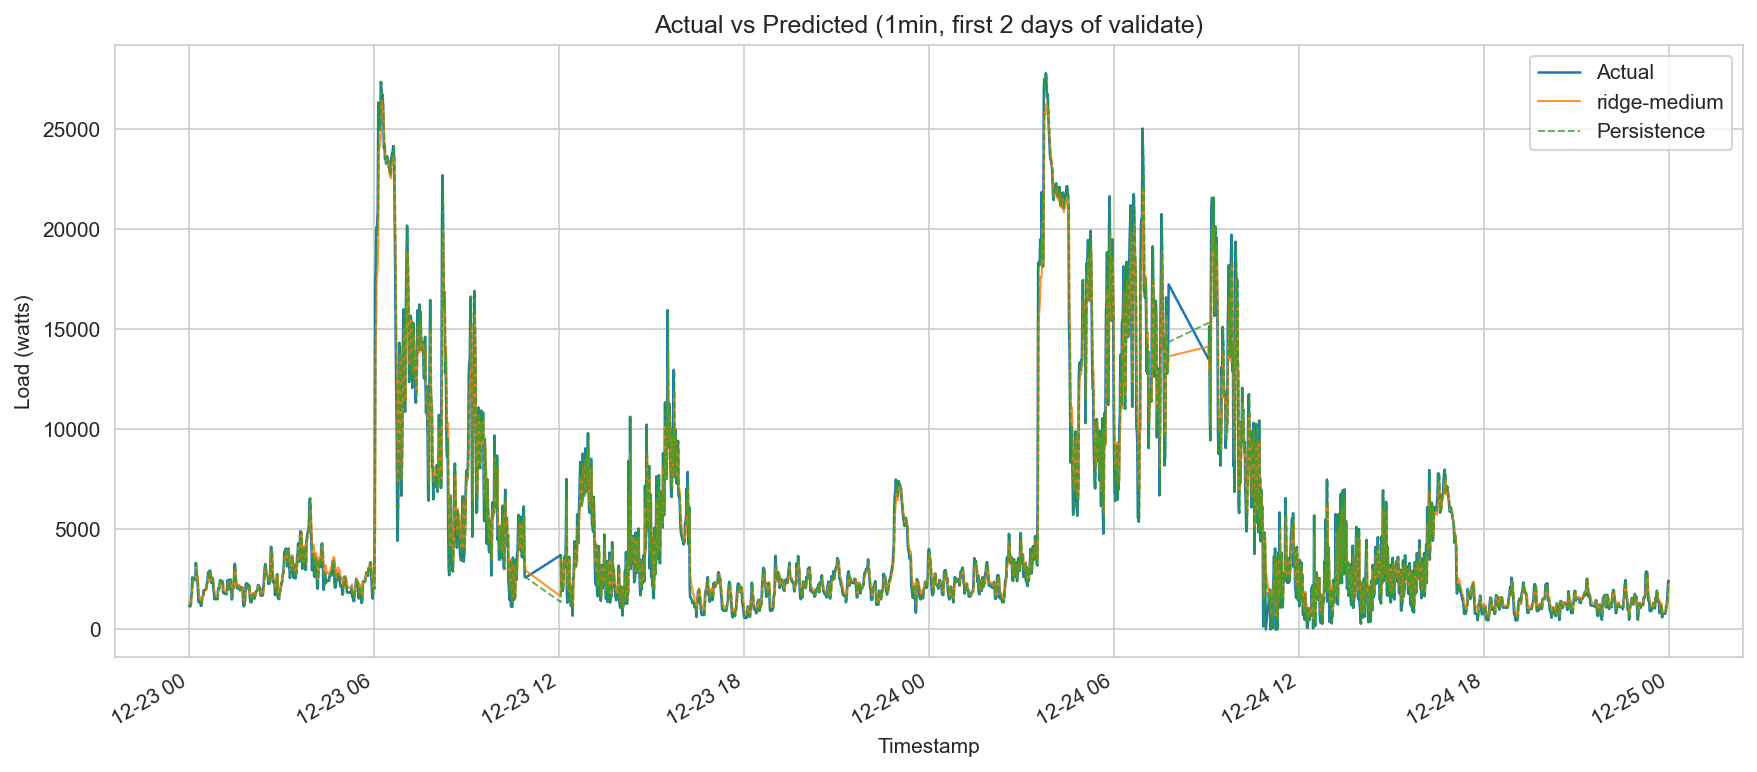

Saved: C:\electric-load-forecasting\outputs\step4_artifacts\fig_actual_vs_predicted.png


In [10]:
def plot_actual_vs_predicted(
    results: list[dict],
    resolution: str = "1min",
    feature_set: str = "curated",
    model_label: str = "ridge-medium",
    n_days: int = 2,
) -> Figure:
    matches = [
        r for r in results
        if r.get("resolution") == resolution
        and r.get("feature_set") == feature_set
        and f"{r['model']}-{r['params']}" == model_label
    ]
    if not matches:
        log.warning("No matching experiment for overlay plot: %s/%s/%s", resolution, feature_set, model_label)
        return plt.figure()

    exp = matches[0]
    y_true = exp["_y_true"]
    y_pred = exp["_y_pred"]
    meta = exp["_meta"]
    ts = pd.to_datetime(meta["timestamp"])

    cutoff = ts.iloc[0] + pd.Timedelta(days=n_days)
    mask = ts < cutoff
    ts = ts[mask]
    yt = y_true[mask.to_numpy()]
    yp = y_pred[mask.to_numpy()]

    df_eval = load_split(resolution, "minimal", "validate").set_index("timestamp")
    y_persist = df_eval.reindex(ts)["lag_1"].to_numpy()

    valid = np.isfinite(y_persist)
    ts = ts[valid]
    yt = yt[valid]
    yp = yp[valid]
    y_persist = y_persist[valid]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(ts, yt, label="Actual", linewidth=1.2)
    ax.plot(ts, yp, label=f"{model_label}", linewidth=1.0, alpha=0.85)
    ax.plot(ts, y_persist, label="Persistence", linewidth=0.9, linestyle="--", alpha=0.8)
    ax.set_title(f"Actual vs Predicted ({resolution}, first {n_days} days of validate)")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (watts)")
    ax.legend(loc="upper right")
    fig.autofmt_xdate(rotation=30)

    out = OUTPUT_DIR / "fig_actual_vs_predicted.png"
    fig.savefig(out)
    plt.show()
    log.info("Saved: %s", out)
    return fig


_ = plot_actual_vs_predicted(all_results)

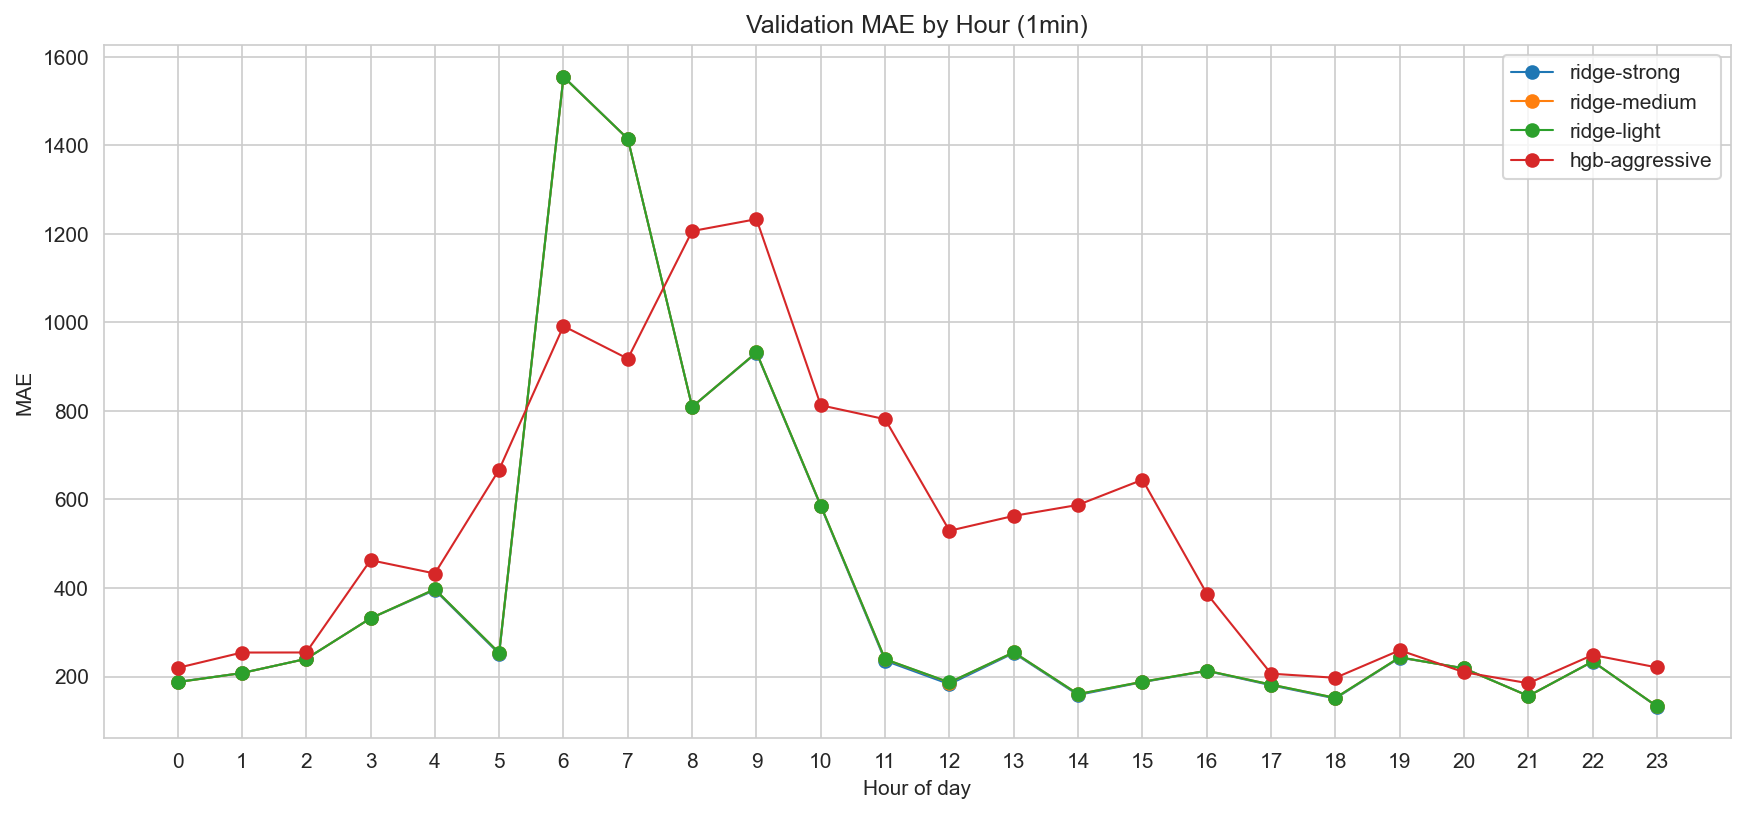

Saved: C:\electric-load-forecasting\outputs\step4_artifacts\fig_error_by_hour.png


In [11]:
def plot_error_by_hour(results: list[dict], resolution: str = "1min", top_n: int = 4) -> Figure:
    best = (
        pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
        .query("resolution == @resolution")
        .sort_values("mae")
        .head(top_n)
    )

    rows = []
    for _, row in best.iterrows():
        match = [
            r for r in results
            if r["resolution"] == row["resolution"]
            and r["feature_set"] == row["feature_set"]
            and r["model"] == row["model"]
            and r["params"] == row["params"]
        ][0]
        hour_metrics = compute_grouped_metrics(
            match["_y_true"],
            match["_y_pred"],
            pd.Series(match["_meta"]["hour"]),
            "hour",
        )
        hour_metrics["model_label"] = f"{row['model']}-{row['params']}"
        rows.append(hour_metrics)

    if not rows:
        return plt.figure()

    plot_df = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(14, 6))
    for label in plot_df["model_label"].unique():
        sub = plot_df[plot_df["model_label"] == label].sort_values("hour")
        ax.plot(sub["hour"], sub["mae"], marker="o", linewidth=1.0, label=label)

    ax.set_xticks(np.arange(24))
    ax.set_title(f"Validation MAE by Hour ({resolution})")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("MAE")
    ax.legend(loc="upper right")

    out = OUTPUT_DIR / "fig_error_by_hour.png"
    fig.savefig(out)
    plt.show()
    log.info("Saved: %s", out)
    return fig


_ = plot_error_by_hour(all_results)


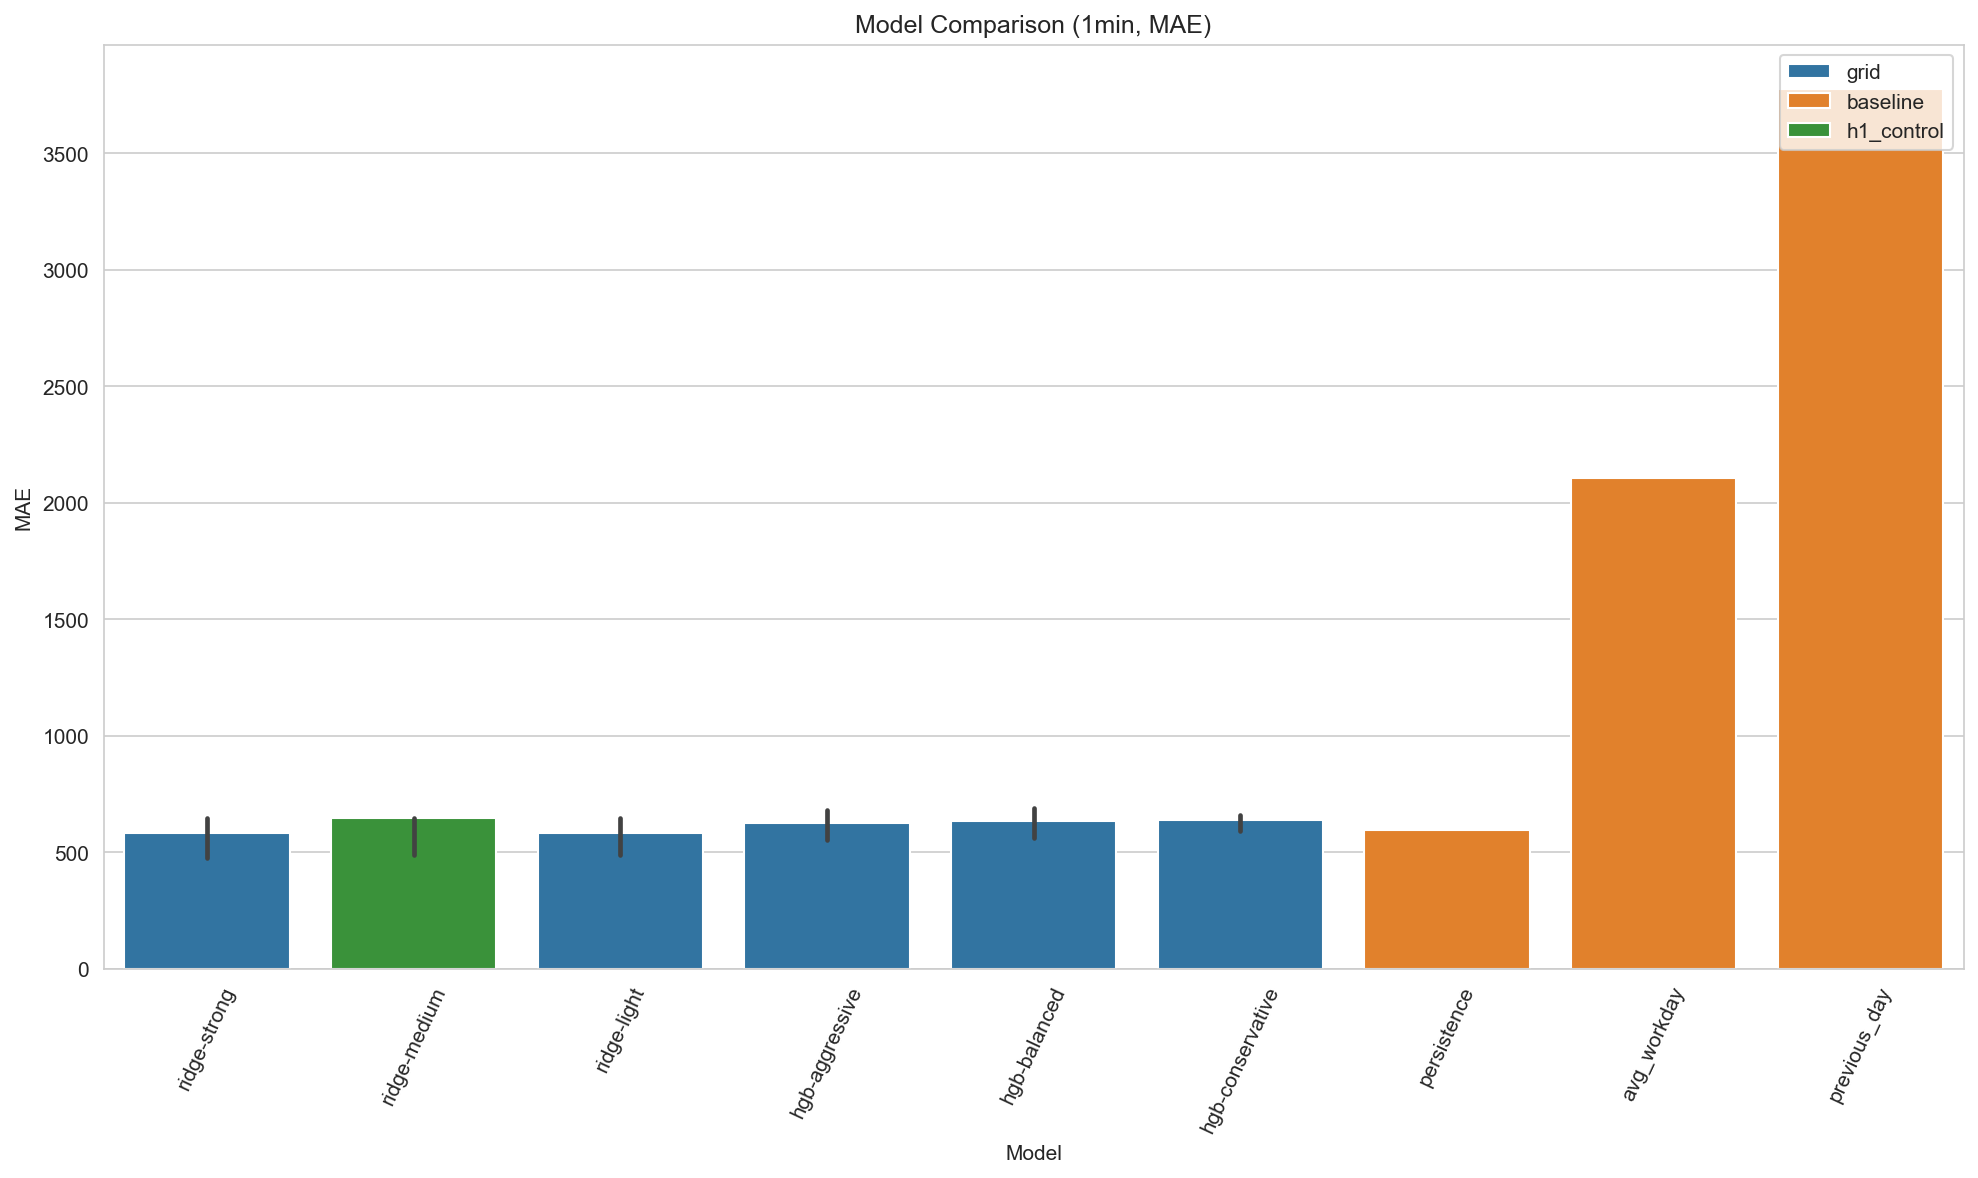

Saved: C:\electric-load-forecasting\outputs\step4_artifacts\fig_model_comparison.png


In [12]:
def plot_model_comparison(df: pd.DataFrame, resolution: str = "1min", metric: str = "mae") -> Figure:
    view_df = (
        df[(df["split"] == "validate") & (df["resolution"] == resolution)]
        .copy()
        .sort_values(metric, ascending=True)
    )

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.barplot(
        x=view_df["model_label"],
        y=view_df[metric],
        hue=view_df["experiment"],
        dodge=False,
        ax=ax,
    )
    ax.set_title(f"Model Comparison ({resolution}, {metric.upper()})")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=65)
    ax.legend(loc="upper right")

    out = OUTPUT_DIR / "fig_model_comparison.png"
    fig.savefig(out)
    plt.show()
    log.info("Saved: %s", out)
    return fig


_ = plot_model_comparison(df_all)

In [13]:
if len(RESOLUTIONS) > 1:
    comp_df = (
        df_all[(df_all["experiment"] == "grid") & (df_all["split"] == "validate")]
        .groupby("resolution", as_index=False)
        .agg(mae=("mae", "min"))
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=comp_df["resolution"], y=comp_df["mae"], ax=ax)
    ax.set_title("Best MAE by Resolution")
    out = OUTPUT_DIR / "fig_resolution_comparison.png"
    fig.savefig(out)
    plt.show()
    log.info("Saved: %s", out)
else:
    log.info("Single resolution MVP: resolution comparison plot deferred")

Single resolution MVP: resolution comparison plot deferred


## Diagnostic Visualizations

Three additional in-notebook diagnostics support model assessment beyond the
saved artifact plots:

1. **Residual distribution** (histogram)
   - **Purpose**: Shows the distribution of prediction errors (actual minus
     predicted) for the best coverage-eligible model to assess error symmetry.
   - **Look for**: A symmetric distribution centered near zero indicates
     unbiased predictions. Right or left skew indicates the model
     systematically under- or over-predicts. Heavy tails indicate occasional
     large errors that RMSE penalizes.

2. **Predicted vs actual scatter** (scatter plot with identity line)
   - **Purpose**: Plots predicted values against actual values to reveal
     systematic bias and heteroscedasticity.
   - **Look for**: Points clustered tightly along the identity line (y = x)
     indicate accurate predictions. Systematic departure from the line at
     high or low load levels indicates range-dependent bias. Fan-shaped spread
     indicates that prediction variance increases with load magnitude.

3. **Train vs validation MAE** (grouped bar chart)
   - **Purpose**: Compares training MAE against validation MAE for each grid
     experiment to assess overfitting.
   - **Look for**: A large gap (train MAE much lower than validation MAE)
     indicates overfitting. HGB models with aggressive depth settings are
     expected to show larger gaps than Ridge models. Consistent gaps across
     feature sets suggest the overfitting is model-driven rather than
     feature-driven.

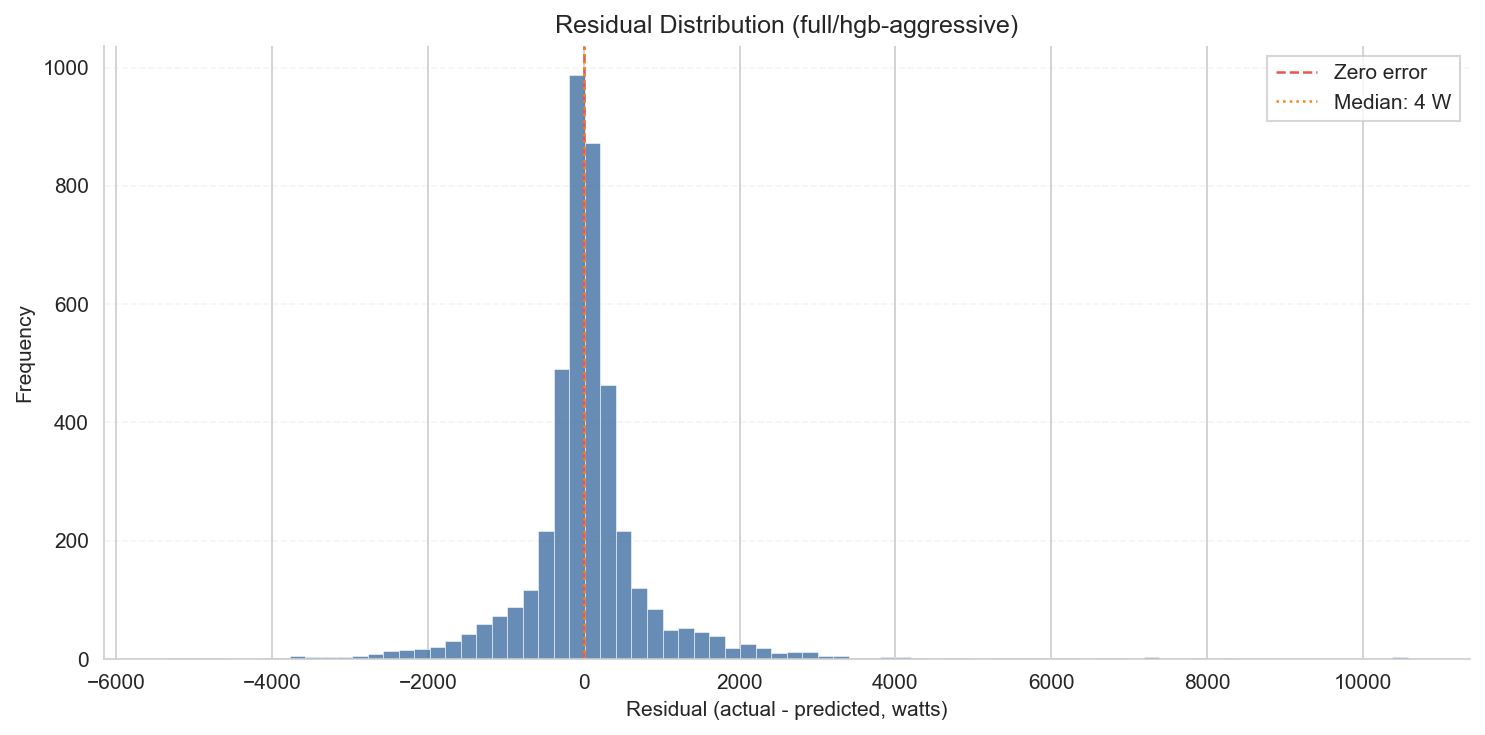

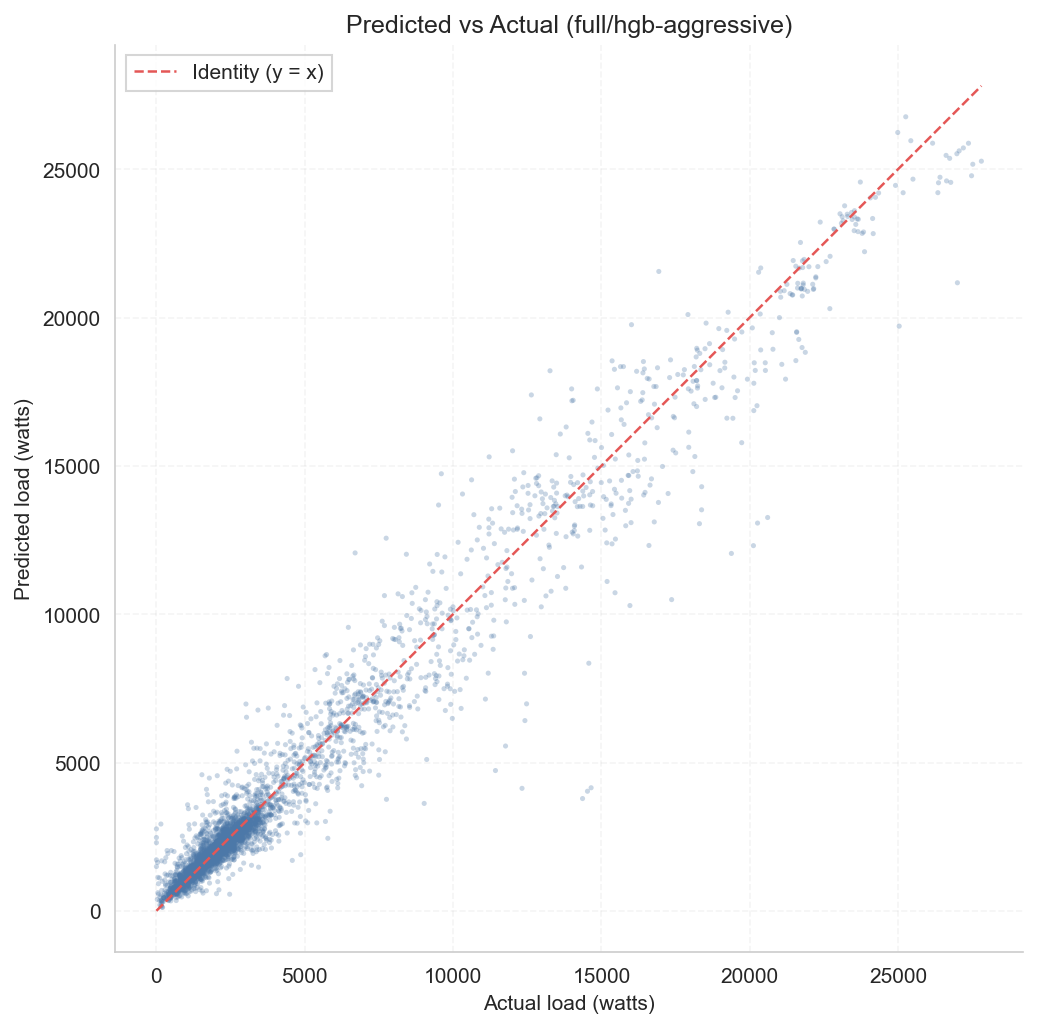

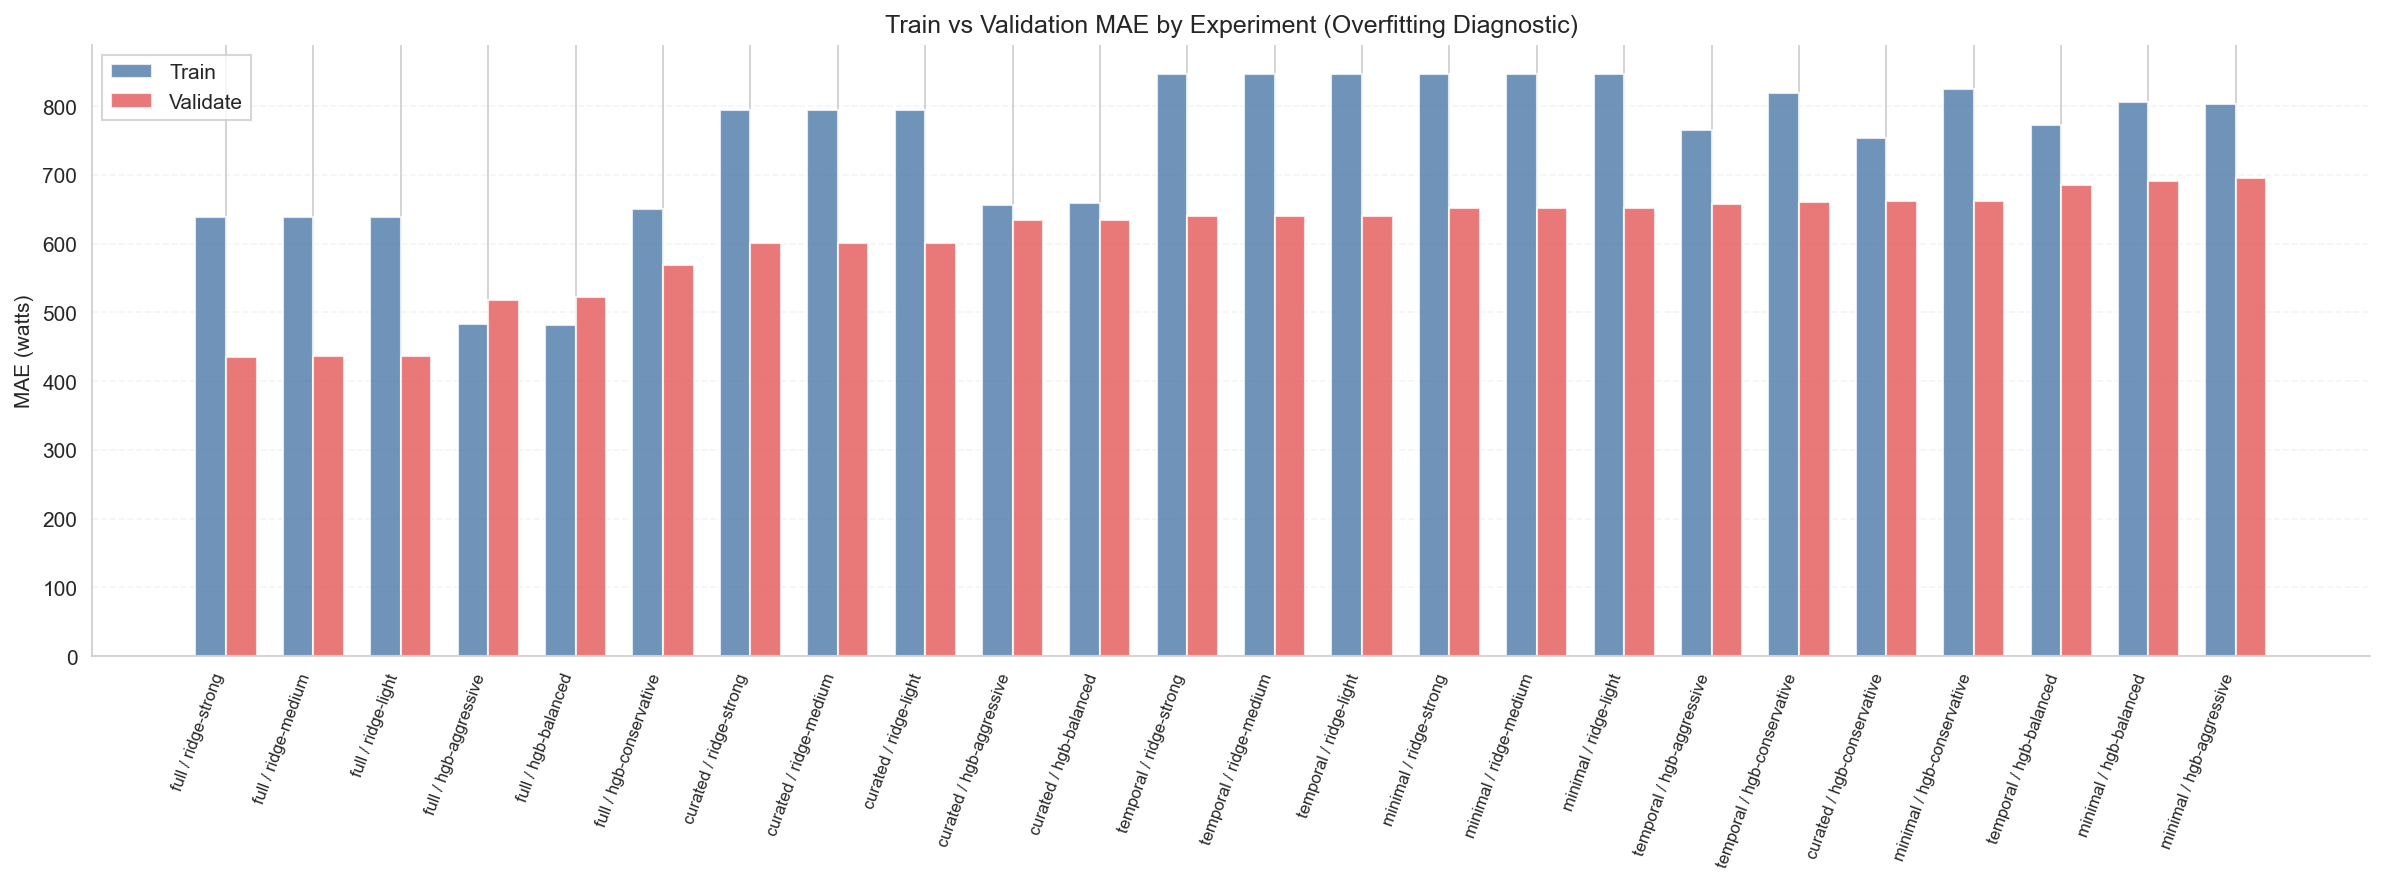

In [14]:
# --- Diagnostic visualizations (not saved as artifacts) ---

# Identify best coverage-eligible model for diagnostic plots.
_diag_eligible = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in all_results])
    .query("resolution == '1min'")
)
_diag_eligible["eval_coverage"] = pd.to_numeric(
    _diag_eligible["eval_coverage"], errors="coerce"
).fillna(0.0)
_diag_eligible = _diag_eligible[_diag_eligible["eval_coverage"] >= MIN_VALIDATE_COVERAGE]

if not _diag_eligible.empty:
    _diag_best_idx = _diag_eligible["mae"].idxmin()
    _diag_best = _diag_eligible.loc[_diag_best_idx]
    _diag_match = [
        r for r in all_results
        if r["resolution"] == _diag_best["resolution"]
        and r["feature_set"] == _diag_best["feature_set"]
        and r["model"] == _diag_best["model"]
        and r["params"] == _diag_best["params"]
    ][0]
    _diag_y_true = _diag_match["_y_true"]
    _diag_y_pred = _diag_match["_y_pred"]
    _diag_label = f"{_diag_best['feature_set']}/{_diag_best['model']}-{_diag_best['params']}"

    # 1. Residual distribution
    residuals = _diag_y_true - _diag_y_pred

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(residuals, bins=80, color="#4c78a8", edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="#e45756", linestyle="--", linewidth=1.2, label="Zero error")
    ax.axvline(
        float(np.median(residuals)), color="#f58518", linestyle=":", linewidth=1.2,
        label=f"Median: {float(np.median(residuals)):,.0f} W",
    )
    ax.set_xlabel("Residual (actual - predicted, watts)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Residual Distribution ({_diag_label})")
    ax.legend(frameon=True, fancybox=False, edgecolor="#cccccc")
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    # 2. Predicted vs actual scatter
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(_diag_y_true, _diag_y_pred, s=6, alpha=0.3, color="#4c78a8", edgecolors="none")
    lims = [
        min(float(_diag_y_true.min()), float(_diag_y_pred.min())),
        max(float(_diag_y_true.max()), float(_diag_y_pred.max())),
    ]
    ax.plot(lims, lims, color="#e45756", linewidth=1.2, linestyle="--", label="Identity (y = x)")
    ax.set_xlabel("Actual load (watts)")
    ax.set_ylabel("Predicted load (watts)")
    ax.set_title(f"Predicted vs Actual ({_diag_label})")
    ax.legend(frameon=True, fancybox=False, edgecolor="#cccccc")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

# 3. Train vs validation MAE (all grid experiments, overfitting diagnostic)
_ovf_df = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in all_results])
    .query("experiment == 'grid' and resolution == '1min'")
    .copy()
)
_ovf_df["model_label"] = _ovf_df["model"] + "-" + _ovf_df["params"]
_ovf_df = _ovf_df.sort_values("mae")

labels = _ovf_df["feature_set"] + " / " + _ovf_df["model_label"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width / 2, _ovf_df["train_mae"].to_numpy(), width, label="Train", color="#4c78a8", alpha=0.8)
ax.bar(x + width / 2, _ovf_df["mae"].to_numpy(), width, label="Validate", color="#e45756", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=8)
ax.set_ylabel("MAE (watts)")
ax.set_title("Train vs Validation MAE by Experiment (Overfitting Diagnostic)")
ax.legend(frameon=True, fancybox=False, edgecolor="#cccccc")
ax.grid(axis="y", alpha=0.2, linestyle="--")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Artifact Export and Run Manifest

This cell exports the unified validation results to CSV, generates per-day-class
and per-hour breakdown files from stashed predictions, and writes the run
manifest JSON with full reproducibility metadata (git commit, seed, feature
sets, model configs, encoding rules, and artifact inventory).

In [15]:
export_cols = [
    "experiment",
    "resolution",
    "feature_set",
    "model",
    "params",
    "model_label",
    "encoding",
    "split",
    "mae",
    "rmse",
    "n_train",
    "n_eval",
    "n_eval_total",
    "eval_coverage",
    "train_mae",
    "train_rmse",
]

for col in ["n_eval_total", "eval_coverage"]:
    if col not in df_all.columns:
        df_all[col] = np.nan

for col in ["feature_set", "encoding"]:
    df_all[col] = df_all[col].astype(object).where(df_all[col].notna(), "n/a")

# metrics_overall (pre-day-ahead state)
df_all[export_cols].to_csv(OUTPUT_DIR / "metrics_overall.csv", index=False, float_format="%.4f")

# metrics_by_day_class and metrics_by_hour from experiment rows only
day_rows = []
hour_rows = []
for r in all_results:
    yt = r["_y_true"]
    yp = r["_y_pred"]
    meta = r["_meta"]

    dc_df = compute_grouped_metrics(yt, yp, meta["day_class"], "day_class")
    hr_df = compute_grouped_metrics(yt, yp, meta["hour"], "hour")

    for df_group, group_col, sink in [(dc_df, "day_class", day_rows), (hr_df, "hour", hour_rows)]:
        df_group = df_group.copy()
        df_group["resolution"] = r["resolution"]
        df_group["feature_set"] = r["feature_set"]
        df_group["model"] = r["model"]
        df_group["params"] = r["params"]
        df_group["model_label"] = f"{r['model']}-{r['params']}"
        cols = ["resolution", "feature_set", "model", "params", "model_label", group_col, "mae", "rmse", "n_rows"]
        sink.append(df_group[cols])

metrics_dc = pd.concat(day_rows, ignore_index=True)
metrics_hr = pd.concat(hour_rows, ignore_index=True)
metrics_dc.to_csv(OUTPUT_DIR / "metrics_by_day_class.csv", index=False, float_format="%.4f")
metrics_hr.to_csv(OUTPUT_DIR / "metrics_by_hour.csv", index=False, float_format="%.4f")


def _git_commit() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True).strip()
    except Exception:
        return "unknown"


manifest = {
    "generated_at": datetime.now().isoformat(),
    "git_commit": _git_commit(),
    "seed": SEED,
    "prediction_mode": "online_single_step",
    "eval_split": "validate",
    "resolutions": RESOLUTIONS,
    "feature_sets": {name: cols for name, cols in FEATURE_SETS.items()},
    "models": {
        f"{m}-{p}": {"class": cfg["class"].__name__, "params": cfg["params"]}
        for (m, p), cfg in MODEL_CONFIGS.items()
    },
    "baselines": [
        "persistence (lag_1)",
        "previous_day (shift by periods_per_day)",
        "avg_workday (mean load by workday+hour from training)",
    ],
    "encoding": {"ridge": "OHE with drop_first=True", "hgb": "raw numeric (no encoding)"},
    "ohe_columns": OHE_COLUMNS,
    "periods_per_day": PERIODS_PER_DAY,
    "min_validate_coverage": MIN_VALIDATE_COVERAGE,
    "total_experiments": int(len(df_all)),
    "artifacts": [
        "metrics_overall.csv",
        "metrics_by_day_class.csv",
        "metrics_by_hour.csv",
        "fig_actual_vs_predicted.png",
        "fig_error_by_hour.png",
        "fig_model_comparison.png",
        "run_manifest.json",
    ],
}
if len(RESOLUTIONS) > 1:
    manifest["artifacts"].append("fig_resolution_comparison.png")


def _json_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(f"Not JSON serializable: {type(obj)}")

with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=_json_serializable)

log.info("Saved artifacts to %s", OUTPUT_DIR)
for name in ["metrics_overall.csv", "metrics_by_day_class.csv", "metrics_by_hour.csv", "run_manifest.json"]:
    log.info("- %s", OUTPUT_DIR / name)


Saved artifacts to C:\electric-load-forecasting\outputs\step4_artifacts


- C:\electric-load-forecasting\outputs\step4_artifacts\metrics_overall.csv


- C:\electric-load-forecasting\outputs\step4_artifacts\metrics_by_day_class.csv


- C:\electric-load-forecasting\outputs\step4_artifacts\metrics_by_hour.csv


- C:\electric-load-forecasting\outputs\step4_artifacts\run_manifest.json


## Day-Ahead Extension and One-Shot Holdout Test

Two final evaluations complete the modeling workflow:

1. **Day-ahead experiment** -- Trains a Ridge model on calendar features plus
   the previous day's load to predict 24 hours ahead. This is not part of the
   grid but provides a separate evidence point for Report IV about longer-
   horizon feasibility. The plot shows one sample day; metrics cover the full
   3-day validation window.

2. **One-shot holdout test** -- Selects the best validation model using
   coverage-guarded ranking (minimum 95% evaluation coverage required), then
   evaluates it exactly once on the held-out test split (days 29-31, Dec 26-28,
   2025). Test baselines are also computed for comparison.

   **Coverage guard**: If the raw-best model by MAE has evaluation coverage
   below the 95% threshold (e.g., Ridge on `full` with 37.5% coverage due to
   NaN cascade), the selector promotes the best model among those meeting the
   threshold. Both the raw best and the selected best are recorded in the run
   manifest for transparency.

   `post_run_validation()` then verifies all 8 expected artifacts exist, checks
   for NaN in metric columns, validates baseline row preservation (B1 guard),
   confirms holdout metadata, and performs lightweight PNG integrity checks.

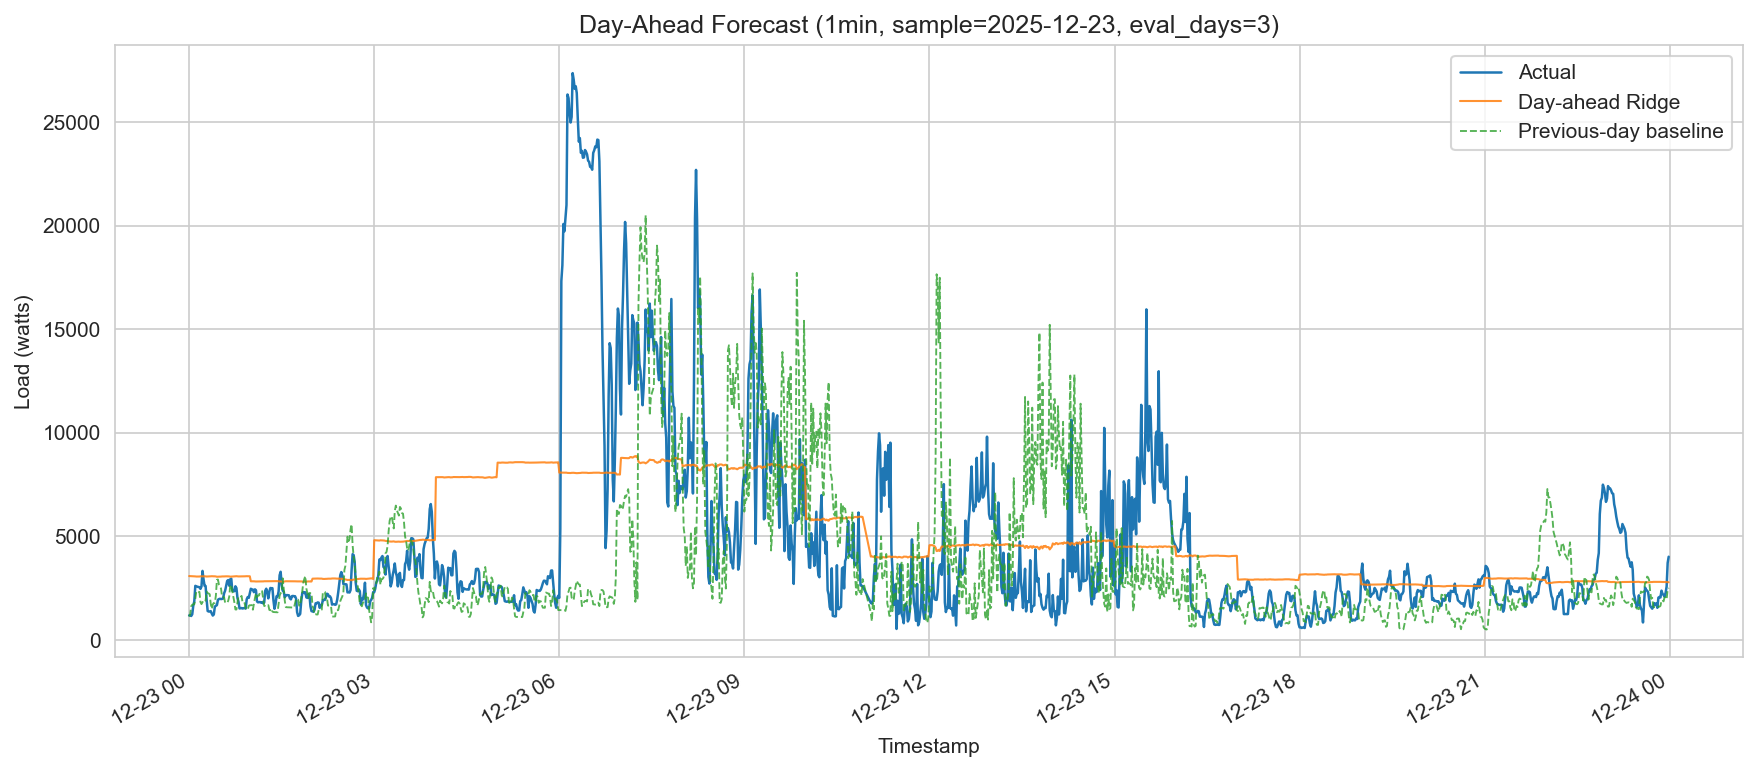

Saved: C:\electric-load-forecasting\outputs\step4_artifacts\fig_day_ahead.png


Coverage guard changed selected model: raw_best=full/ridge-strong (coverage=0.375, mae=435.00) -> selected=full/hgb-aggressive (coverage=1.000, mae=517.45)


Updated metrics_overall.csv rows=33


Selected 1min holdout model: full/hgb-aggressive MAE=517.45 coverage=1.000 (4296/4296)


post_run_validation passed


In [16]:
def run_day_ahead_experiment(resolution: str = "1min") -> dict:
    df_gold = load_gold(resolution).sort_values("timestamp").copy()
    periods = PERIODS_PER_DAY[resolution]
    df_gold["prev_day_load"] = df_gold[TARGET_COLUMN].shift(periods)

    # Evaluate across full validation window; keep first day for visualization.
    start_day, end_day = SPLIT_DAY_RANGES["validate"]
    days = pd.Index(df_gold["timestamp"].dt.normalize().unique()).sort_values()
    validate_dates = pd.DatetimeIndex(days[start_day - 1 : end_day])
    if len(validate_dates) == 0:
        raise RuntimeError("No validation dates resolved for day-ahead experiment")
    sample_date = pd.Timestamp(validate_dates[0])

    train_df = df_gold[df_gold["timestamp"].dt.normalize() < sample_date].copy()
    val_df = df_gold[df_gold["timestamp"].dt.normalize().isin(validate_dates)].copy()
    eval_total = int(val_df[TARGET_COLUMN].notna().sum())

    feature_cols = ["workday", "hour", "day_of_week", "season", "time_of_day", "prev_day_load"]

    train_df = train_df.dropna(subset=feature_cols + [TARGET_COLUMN])
    val_df = val_df.dropna(subset=feature_cols + [TARGET_COLUMN])

    x_train = train_df[feature_cols].copy()
    y_train = train_df[TARGET_COLUMN].copy()
    x_val = val_df[feature_cols].copy()
    y_val = val_df[TARGET_COLUMN].copy()

    x_train_e, x_val_e = encode_for_ridge(x_train, x_val)

    model = Ridge(alpha=1.0)
    model.fit(x_train_e, y_train)
    y_pred = model.predict(x_val_e)
    y_train_pred = model.predict(x_train_e)

    # Plot sample-day profile against actual + previous-day baseline.
    pred_series = pd.Series(y_pred, index=val_df.index)
    plot_mask = val_df["timestamp"].dt.normalize() == sample_date
    ts = val_df.loc[plot_mask, "timestamp"]
    y_plot = val_df.loc[plot_mask, TARGET_COLUMN].to_numpy()
    y_pred_plot = pred_series.loc[plot_mask].to_numpy()
    y_prev = val_df.loc[plot_mask, "prev_day_load"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(ts, y_plot, label="Actual", linewidth=1.2)
    ax.plot(ts, y_pred_plot, label="Day-ahead Ridge", linewidth=1.0, alpha=0.85)
    ax.plot(ts, y_prev, label="Previous-day baseline", linewidth=0.9, linestyle="--", alpha=0.8)
    ax.set_title(
        f"Day-Ahead Forecast ({resolution}, sample={sample_date.date()}, eval_days={len(validate_dates)})"
    )
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (watts)")
    ax.legend(loc="upper right")
    fig.autofmt_xdate(rotation=30)

    out = OUTPUT_DIR / "fig_day_ahead.png"
    fig.savefig(out)
    plt.show()
    log.info("Saved: %s", out)

    return {
        "experiment": "day_ahead",
        "resolution": resolution,
        "feature_set": "day_ahead_calendar+prev_day",
        "model": "ridge",
        "params": "medium",
        "model_label": "ridge-medium",
        "encoding": "ohe",
        "split": "validate",
        "mae": float(mean_absolute_error(y_val, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_val, y_pred))),
        "n_train": int(len(x_train_e)),
        "n_eval": int(len(x_val_e)),
        "n_eval_total": eval_total,
        "eval_coverage": _coverage(int(len(x_val_e)), eval_total),
        "train_mae": float(mean_absolute_error(y_train, y_train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_train_pred))),
    }


da_row = run_day_ahead_experiment("1min")

# Idempotent rewrite: remove existing day_ahead then append one row.
df_non_da = df_all[df_all["experiment"] != "day_ahead"].copy()
df_all = pd.concat([df_non_da, pd.DataFrame([da_row])], ignore_index=True)
for col in ["feature_set", "encoding"]:
    df_all[col] = df_all[col].astype(object).where(df_all[col].notna(), "n/a")
df_all[export_cols].to_csv(OUTPUT_DIR / "metrics_overall.csv", index=False, float_format="%.4f")

# Refresh manifest with final validation artifact state.
manifest_path = OUTPUT_DIR / "run_manifest.json"
if manifest_path.exists():
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)
else:
    manifest = {}

manifest["generated_at"] = datetime.now().isoformat()
manifest["total_experiments"] = int(len(df_all))
artifacts = list(manifest.get("artifacts", []))
if "fig_day_ahead.png" not in artifacts:
    artifacts.append("fig_day_ahead.png")
manifest["artifacts"] = artifacts

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# Build one-shot holdout/test evaluation for best model at 1min with coverage guard.
mask_grid_val = (
    (df_all["experiment"] == "grid")
    & (df_all["resolution"] == "1min")
    & (df_all["split"] == "validate")
)
rank_source = df_all[mask_grid_val].copy()
rank_source["eval_coverage"] = pd.to_numeric(rank_source["eval_coverage"], errors="coerce").fillna(0.0)

best_raw = rank_source.sort_values("mae").iloc[0]
eligible = rank_source[rank_source["eval_coverage"] >= MIN_VALIDATE_COVERAGE]
if len(eligible) == 0:
    best = rank_source.sort_values(["eval_coverage", "mae"], ascending=[False, True]).iloc[0]
    selection_reason = f"fallback_highest_coverage_then_mae (threshold={MIN_VALIDATE_COVERAGE:.2f})"
else:
    best = eligible.sort_values("mae").iloc[0]
    selection_reason = (
        f"coverage_guard_mae (threshold={MIN_VALIDATE_COVERAGE:.2f}, eligible={len(eligible)}/{len(rank_source)})"
    )

if str(best_raw.get("feature_set")) != str(best.get("feature_set")) or str(best_raw.get("model")) != str(best.get("model")) or str(best_raw.get("params")) != str(best.get("params")):
    log.warning(
        "Coverage guard changed selected model: raw_best=%s/%s-%s (coverage=%.3f, mae=%.2f) -> selected=%s/%s-%s (coverage=%.3f, mae=%.2f)",
        best_raw["feature_set"], best_raw["model"], best_raw["params"], float(best_raw["eval_coverage"]), float(best_raw["mae"]),
        best["feature_set"], best["model"], best["params"], float(best["eval_coverage"]), float(best["mae"]),
    )

best_result = run_experiment(
    resolution="1min",
    feature_set_name=str(best["feature_set"]),
    model_name=str(best["model"]),
    param_label=str(best["params"]),
    eval_split="test",
)

# Test baselines
test_baselines = pd.DataFrame(compute_baselines("1min", split="test"))

for col in ["feature_set", "encoding"]:
    test_baselines[col] = test_baselines[col].astype(object).where(test_baselines[col].notna(), "n/a")

test_model_row = {k: v for k, v in best_result.items() if not k.startswith("_")}
test_model_row["model_label"] = f"{test_model_row['model']}-{test_model_row['params']}"

# IMPORTANT: do not read CSV with default NA parsing here; keep in-memory df_all so 'n/a' stays literal.
df_val_only = df_all[df_all["split"].astype(str) != "test"].copy()
df_test_block = pd.concat([
    pd.DataFrame([test_model_row])[export_cols],
    test_baselines.assign(model_label=test_baselines["model"])[export_cols],
], ignore_index=True)

for col in ["feature_set", "encoding"]:
    df_val_only[col] = df_val_only[col].astype(object).where(df_val_only[col].notna(), "n/a")
    df_test_block[col] = df_test_block[col].astype(object).where(df_test_block[col].notna(), "n/a")

df_final = pd.concat([df_val_only[export_cols], df_test_block], ignore_index=True)
df_final.to_csv(OUTPUT_DIR / "metrics_overall.csv", index=False, float_format="%.4f")

manifest["has_test"] = True
manifest["test_generated_at"] = datetime.now().isoformat()
manifest["total_experiments"] = int(len(df_final))
manifest["selection_policy"] = selection_reason
manifest["best_per_resolution"] = {
    "1min": {
        "raw_best_by_mae": {
            "feature_set": str(best_raw["feature_set"]),
            "model": str(best_raw["model"]),
            "params": str(best_raw["params"]),
            "validation_mae": float(best_raw["mae"]),
            "eval_coverage": float(best_raw["eval_coverage"]),
            "n_eval": int(best_raw["n_eval"]),
            "n_eval_total": int(best_raw["n_eval_total"]),
        },
        "selected_for_holdout": {
            "feature_set": str(best["feature_set"]),
            "model": str(best["model"]),
            "params": str(best["params"]),
            "validation_mae": float(best["mae"]),
            "eval_coverage": float(best["eval_coverage"]),
            "n_eval": int(best["n_eval"]),
            "n_eval_total": int(best["n_eval_total"]),
        },
    }
}
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

log.info("Updated metrics_overall.csv rows=%d", len(df_final))
log.info(
    "Selected 1min holdout model: %s/%s-%s MAE=%.2f coverage=%.3f (%d/%d)",
    best['feature_set'],
    best['model'],
    best['params'],
    float(best['mae']),
    float(best['eval_coverage']),
    int(best['n_eval']),
    int(best['n_eval_total']),
)


def post_run_validation() -> None:
    expected = [
        "metrics_overall.csv",
        "metrics_by_day_class.csv",
        "metrics_by_hour.csv",
        "run_manifest.json",
        "fig_actual_vs_predicted.png",
        "fig_error_by_hour.png",
        "fig_model_comparison.png",
        "fig_day_ahead.png",
    ]

    missing = [name for name in expected if not (OUTPUT_DIR / name).exists()]
    if missing:
        raise RuntimeError(f"Missing artifacts: {missing}")

    overall = pd.read_csv(OUTPUT_DIR / "metrics_overall.csv", keep_default_na=False)
    splits = set(overall["split"].astype(str).unique())
    if "validate" not in splits or "test" not in splits:
        raise RuntimeError(f"metrics_overall missing split(s): {splits}")

    if overall[["mae", "rmse"]].isna().any().any():
        raise RuntimeError("metrics_overall has NaN in mae/rmse")

    base_mask = overall["model"].isin(["persistence", "previous_day", "avg_workday"])
    base_rows = overall[base_mask]
    if base_rows.empty:
        raise RuntimeError("No baseline rows found in metrics_overall")

    # B1 guard: keep literal 'n/a' instead of NA conversion.
    for col in ["feature_set", "encoding"]:
        if (base_rows[col].astype(str).str.lower() != "n/a").any():
            bad = base_rows.loc[base_rows[col].astype(str).str.lower() != "n/a", ["split", "model", col]]
            raise RuntimeError(f"Baseline column {col} not preserved as 'n/a': {bad.to_dict(orient='records')}")

    with open(OUTPUT_DIR / "run_manifest.json", "r", encoding="utf-8") as f:
        mf = json.load(f)
    if mf.get("has_test") is not True:
        raise RuntimeError("run_manifest.has_test is not true")

    if "selection_policy" not in mf:
        raise RuntimeError("run_manifest missing selection_policy")

    # Lightweight visual integrity check for PNGs.
    for name in ["fig_actual_vs_predicted.png", "fig_error_by_hour.png", "fig_model_comparison.png", "fig_day_ahead.png"]:
        p = OUTPUT_DIR / name
        if p.stat().st_size < 1000:
            raise RuntimeError(f"PNG looks too small: {p}")
        _ = plt.imread(p)

    if "df_hypotheses" not in globals() or len(df_hypotheses) < 4:
        raise RuntimeError("Hypothesis evaluation output missing or incomplete")

    log.info("post_run_validation passed")


post_run_validation()


## Key Findings

- **Persistence is a strong baseline.** At 1-minute resolution, the lag-1
  persistence baseline achieves MAE 594.7 W, which is already competitive with
  several trained models. This reflects the strong short-term autocorrelation
  in the load signal.
- **Feature depth drives improvement.** The best validation MAE among
  full-coverage models is 517.4 W (full/hgb-aggressive), a 13.0% improvement
  over persistence. Richer feature sets consistently outperform minimal and
  temporal sets across both model families.
- **Coverage asymmetry requires careful interpretation.** Ridge models on the
  `full` feature set evaluate on only 37.5% of validation rows due to the
  `rolling_*_1440` NaN cascade, producing artificially low MAE values (435.0 W)
  that are not directly comparable to full-coverage experiments. The coverage
  guard selects the best full-coverage model for holdout evaluation.
- **H1 (workday signal) did not meet the 10% target.** The observed MAE delta
  was -0.63%, indicating that the `workday` feature does not meaningfully
  improve the minimal model when lag_1 is already present. This likely reflects
  that lag_1 already captures the workday effect implicitly.
- **H2 (lag/rolling context) showed improvement but below target.** Curated
  features improved RMSE by 4.56% over the temporal set, short of the 8%
  target but directionally consistent with the hypothesis.
- **Holdout test showed favorable shift.** The selected model (full/hgb-
  aggressive) achieved test MAE 201.4 W versus validation MAE 517.4 W, a
  -46.2% shift. The test period (Dec 26-28) was substantially easier to
  predict than the validation period (Dec 23-25, which includes Christmas Eve
  and Christmas Day transitions).
- **Day-ahead forecasting has limited accuracy.** The day-ahead Ridge model
  achieved MAE 2,665.8 W, well above the online single-step models but below
  the previous-day baseline (3,777.8 W), confirming that calendar features
  carry some signal for longer horizons.

## Glossary

| Term | Definition | Context |
|------|------------|---------|
| avg_load | The arithmetic mean of load readings within each resampled interval, serving as the modeling target variable. | Target column |
| avg_workday baseline | A baseline that predicts load as the mean of all training observations sharing the same (workday, hour) combination. | Baseline computation |
| coverage guard | A model selection policy that requires minimum evaluation coverage (default 95%) before a model is eligible for holdout testing. Prevents selecting models evaluated on small subsets due to NaN filtering. | Model selection |
| curated feature set | A reduced subset of 11 predictors selected to balance predictive power with manageable collinearity: workday, hour, season, time_of_day, lag_1, lag_5, lag_60, lag_1440, rolling_mean_15, rolling_std_60, slope_15. | Feature engineering |
| day-ahead experiment | A supplementary experiment that predicts load 24 hours in advance using only calendar features and the previous day's load, providing evidence about longer-horizon feasibility. | Forecast horizon |
| day_class | An operational label classifying each calendar day as full (working), half (partial), or none (non-working). | Business context |
| determinism check | A verification that re-running the same experiment with the same seed produces identical MAE and RMSE within floating-point tolerance. | Reproducibility |
| eval_coverage | The ratio of evaluation rows scored (n_eval) to total available evaluation rows (n_eval_total). Coverage below 100% indicates that NaN filtering removed rows from the evaluation set. | Data quality metric |
| full feature set | The broadest predictor set (41 features), including all calendar, lag, rolling, delta, and slope features from the gold schema. Requires regularization due to high collinearity. | Feature engineering |
| H1 (workday signal) | Hypothesis that including the workday feature improves MAE by at least 10% compared to a temporal-only control without workday. | Hypothesis evaluation |
| H2 (lag/rolling context) | Hypothesis that adding lag and rolling features to the temporal set improves RMSE by at least 8%. | Hypothesis evaluation |
| H3 (resolution tradeoff) | Hypothesis that coarser resolutions degrade MAE by no more than 5%. Deferred to future multi-resolution work. | Hypothesis evaluation |
| H4 (nonlinear behavior) | Exploratory comparison of HGB vs Ridge on the same feature set to assess whether tree-based models capture nonlinear load patterns. No hard pass/fail threshold. | Hypothesis evaluation |
| HistGradientBoostingRegressor (HGB) | A gradient-boosted tree ensemble from scikit-learn that handles NaN values natively, does not require one-hot encoding, and captures nonlinear feature interactions. | Model family |
| holdout test | A single, one-shot evaluation of the selected model on the test split (days 29-31). Never used for model tuning or selection. | Evaluation protocol |
| minimal feature set | The simplest predictor set (3 features): workday, hour, lag_1. Serves as the MVMP baseline. | Feature engineering |
| n_eval | The number of evaluation rows on which a model was actually scored, after NaN filtering. | Evaluation metric |
| n_eval_total | The total number of evaluation rows available before any NaN filtering. | Evaluation metric |
| NaN cascade | A structured pattern where features with large rolling windows (e.g., rolling_*_1440) produce NaN at time gaps in the gold series. Ridge models drop these rows, reducing evaluation coverage. HGB models handle NaN natively. | Data quality |
| OHE (one-hot encoding) | A categorical encoding that creates binary columns for each category level, with `drop_first=True` to avoid multicollinearity. Applied to Ridge models only. | Encoding |
| online single-step | A prediction mode where the model predicts one step ahead using the actual observed value at t-1 as input, rather than its own previous predictions. | Prediction mode |
| persistence baseline | A naive forecast that predicts the next value as the most recent observation (lag_1). The strongest naive benchmark for high-frequency time series. | Baseline |
| periods_per_day | The number of time steps in a 24-hour day at the current resolution (1,440 at 1-minute resolution). Used to compute the previous-day baseline shift. | Resolution parameter |
| previous-day baseline | A baseline that predicts load by shifting the gold-layer series by `periods_per_day` steps, using the same minute from the prior calendar day. | Baseline |
| residual | The difference between actual and predicted values (actual minus predicted). Positive residuals indicate under-prediction; negative indicate over-prediction. | Error analysis |
| Ridge regression | A linear regression model with L2 regularization controlled by the alpha parameter. Higher alpha increases regularization, reducing coefficient magnitudes. | Model family |
| run manifest | A JSON file (`run_manifest.json`) that records the complete configuration, seed, git commit, selection policy, and artifact inventory for reproducibility. | Artifact |
| temporal feature set | A mid-range predictor set (10 features) combining calendar features (workday, year, quarter, month, day, day_of_week, hour, season, time_of_day) with lag_1. | Feature engineering |
| workday | A numeric encoding of the day-class label (1.0 = full, 0.5 = half, 0.0 = none) used as a predictor feature. | Business feature |